#Question 2

In [4]:
%pip install pandas sqlalchemy psycopg2-binary

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
from sqlalchemy import create_engine

In [6]:
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from getpass import getpass

password = getpass("Enter PostgreSQL password: ")

db_url = URL.create(
    drivername="postgresql+psycopg2",
    username="postgres",
    password=password,
    host="localhost",
    port=5432,
    database="World"
)

engine = create_engine(db_url)

print("Database engine created!")

Database engine created!


In [7]:
print("Password received:", bool(password))

Password received: True


In [8]:
with engine.connect() as connection:
    print("Successfully connected to World database!")

Successfully connected to World database!


In [9]:
# Statement 1: Define the SQL query
query = """
SELECT
    c.name AS country_name,
    COUNT(cl.language) AS official_language_count
FROM country AS c
JOIN countrylanguage AS cl
    ON c.code = cl.countrycode
WHERE cl.isofficial = 'T'
GROUP BY c.code, c.name
HAVING COUNT(cl.language) > 2
ORDER BY official_language_count DESC;
"""



In [10]:
# Statement 2: Execute the query
df = pd.read_sql_query(query, engine)



In [11]:
# Statement 3: Display the results
display(df)

,country_name,official_language_count
0,Switzerland ...,4
1,South Africa ...,4
2,Bolivia ...,3
3,Peru ...,3
4,Vanuatu ...,3
5,Belgium ...,3
6,Luxembourg ...,3
7,Singapore ...,3


#Question 3

In [12]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [13]:
import matplotlib.pyplot as plt

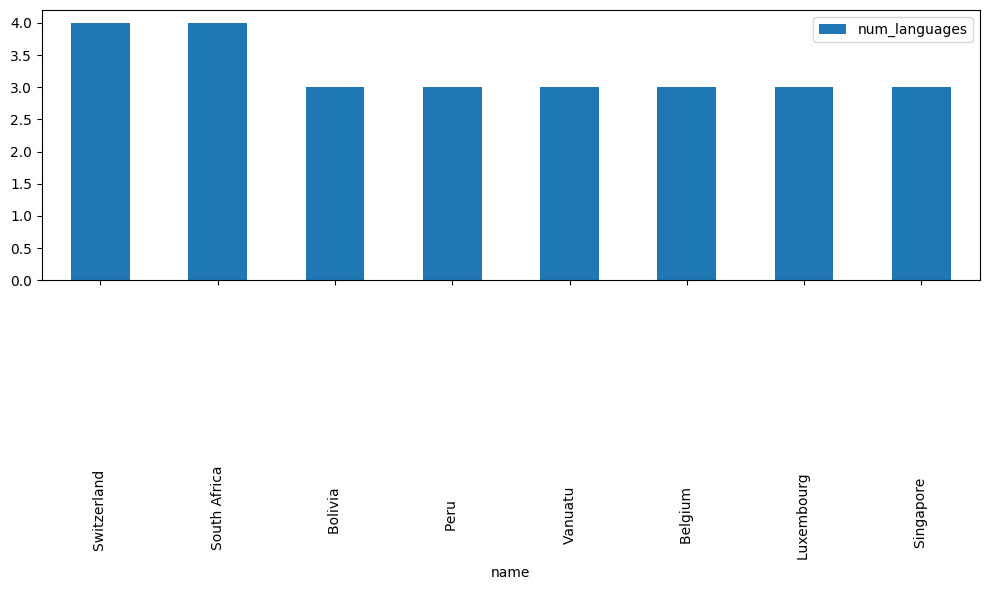

In [15]:
# Question 3: Graph of countries with more than two official languages

import matplotlib.pyplot as plt

# Rename columns to match the example graph
graph_df = df.rename(columns={
    'country_name': 'name',
    'official_language_count': 'num_languages'
})

# Create the bar chart
graph_df.plot(
    kind='bar',
    x='name',
    y='num_languages',
    figsize=(10, 6)
)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()